### 목표
 - 500명의 키와 몸무게, 비만도 라벨을 이용해서 비만을 판단하는 모델을 만들어보자
 - 머신러닝 7과정을 이해해보자

### 머신러닝 7과정
1. 문제정의 : 지도학습을 할지 비지도 학습을 할지, 필요한 데이터 정의, 지도 학습을 하면 분류 vs 회귀
2. 데이터 수집 : file, 크롤링, db,공공데이터포털, 센서수집, 설문조사
3. 데이터 전처리(preprocessing) : 결측치, 이상치 처리, 특성 공학 등
4. 탐색적 데이터 분석(EDA) : 특성 의미 파악, 기술통계량 확인, 특성 선택 등
5. 모델 선택 및 하이퍼파라미터 조정
6. 모델 학습( 및 예측)
7. 모델 평가
- 여기서 끝이아니라 평가 점수가 낮다면 위의 순서중 필요한 곳으로 돌아가서 다시 하기도 한다.

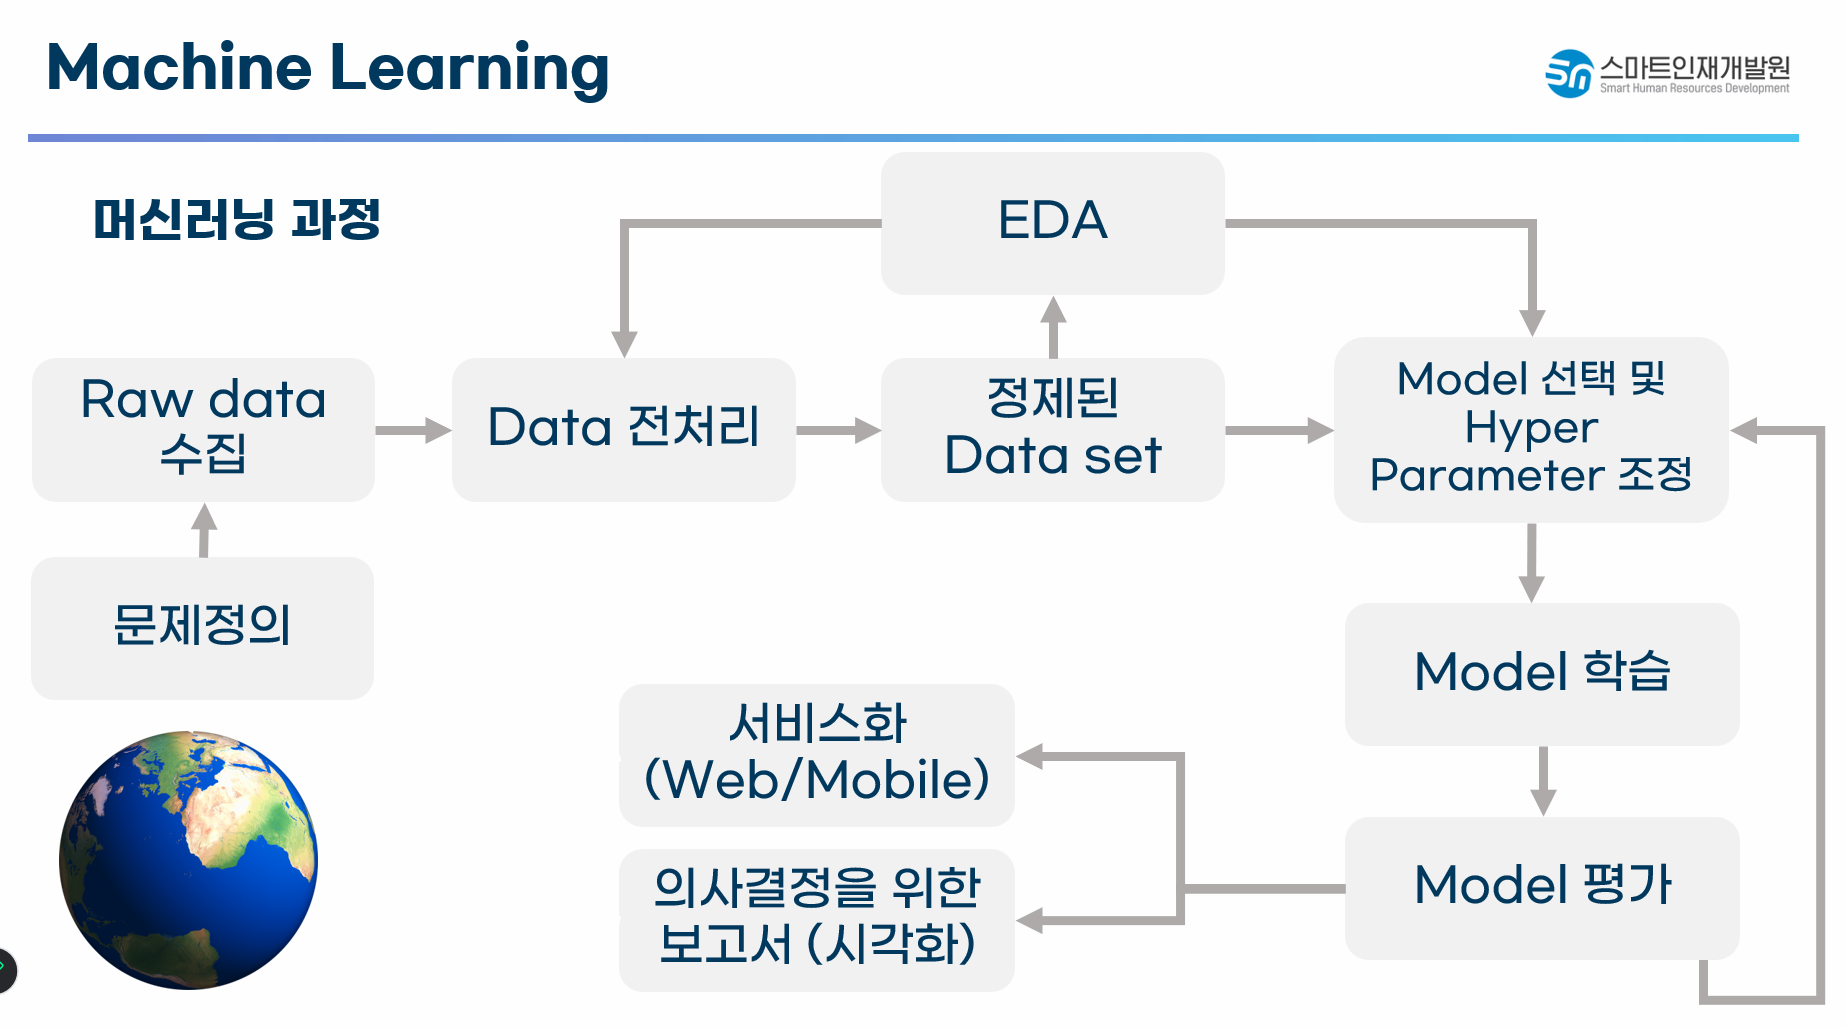

In [3]:
# 머신러닝 필수 라이브러리 설치
#!pip install scikit-learn

#### 1. 문제 정의
 - 500명의 키/몸무게 데이터를 활용해서 비만 정도 판단 모델 설계

#### 2. 데이터 수집
- csv 파일 불러오기

In [10]:
# 필요한 도구 불러오기
# 분석 특화 3대장(n, p, m)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 변수 data에 bmi_500.csv 파일 담기
data = pd.read_csv('./data/bmi_500.csv') # label컬럼을 제일 앞으로 옮기고 싶을때 괄호 안에 , index_col='Label' 넣으면 됨 
data

,Gender,Height,Weight,Label
0,Male,174,96,Obesity
1,Male,189,87,Normal
2,Female,185,110,Obesity
3,Female,195,104,Overweight
4,Male,149,61,Overweight
...,...,...,...,...
495,Female,150,153,Extreme Obesity
496,Female,184,121,Obesity
497,Female,141,136,Extreme Obesity
498,Male,150,95,Extreme Obesity


In [12]:
# 라벨 컬럼을 제일 앞으로 옮기는 방법.(이미 데이터를 불러온 후에)
# 방법 1
# data = data.set_index('Label')

# 방법 2
data.set_index('Label', inplace = True)

In [13]:
data

,Gender,Height,Weight
Label,,,
Obesity,Male,174,96
Normal,Male,189,87
Obesity,Female,185,110
Overweight,Female,195,104
Overweight,Male,149,61
...,...,...,...
Extreme Obesity,Female,150,153
Obesity,Female,184,121
Extreme Obesity,Female,141,136


#### 3. 데이터 전처리
 -  결측치/이상치 처리, 특성공학

In [15]:
data.info()  

# 로 확인해보니 결측치 x. 학습용 데이터라 딱히 전처리 할건 없음.

<class 'pandas.DataFrame'>
Index: 500 entries, Obesity to Extreme Obesity
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Gender  500 non-null    str  
 1   Height  500 non-null    int64
 2   Weight  500 non-null    int64
dtypes: int64(2), str(1)
memory usage: 23.2 KB


#### 4. EDA(탐색적 데이터 분석)
- 데이터 특성 파악

In [18]:
# 기술통계량(평균, 중앙값, 표준편차, ...) 확인하기 -> describe() 함수 사용
data.describe()

# count : 개수
# mean : 평균
# std : 표준편차
# min : 최솟값
# 25%, 50%, 75% : 1분위수, 2분위수, 3분위수
# max : 최댓값


# 기본적으로는 수치형 데이터에 대해서만 확인 가능하다! -> 젠더 컬럼 표시안됨

,Height,Weight
count,500.000000,500.000000
mean,169.944000,106.000000
std,16.375261,32.382607
min,140.000000,50.000000
25%,156.000000,80.000000
50%,170.500000,106.000000
75%,184.000000,136.000000
max,199.000000,160.000000


In [17]:
# std값이 실수 형이라 나머지 값들도 정수형에서 실수형으로 바껴서 출력됨.

In [19]:
# 문자열 데이터도 적용해보기!
data.describe(include = 'str') # --문자형도 포함해서 보여달라!

# count : 개수
# unique : 고유값(값의 종류가 몇개인지)
# top : 최빈값(가장 많이 나온 종류)
# freq : 최빈값의 빈도수

,Gender
count,500
unique,2
top,Female
freq,255


In [20]:
# 문자열, 숫자형 데이터 한꺼번에 확인하기
data.describe(include = 'all')

,Gender,Height,Weight
count,500,500.000000,500.000000
unique,2,NaN,NaN
top,Female,NaN,NaN
freq,255,NaN,NaN
mean,NaN,169.944000,106.000000
std,NaN,16.375261,32.382607
min,NaN,140.000000,50.000000
25%,NaN,156.000000,80.000000
50%,NaN,170.500000,106.000000
75%,NaN,184.000000,136.000000


In [23]:
# 정답(label)의 종류 개수 확인하기
data.index.unique() #6개

Index(['Obesity', 'Normal', 'Overweight', 'Extreme Obesity', 'Weak',
       'Extremely Weak'],
      dtype='str', name='Label')

In [26]:
# 'Normal'인 사람은 몇명일까요?
data.loc['Normal'].shape

(69, 3)

In [29]:
# data['Label'].value_counts()   ---> 원본 데이터프레임 상태일때 라벨컬럼으로 갯수확인할때

In [27]:
# 정답 별 데이터 수 확인하기
data.index.value_counts()

Label
Extreme Obesity    198
Obesity            130
Normal              69
Overweight          68
Weak                22
Extremely Weak      13
Name: count, dtype: int64

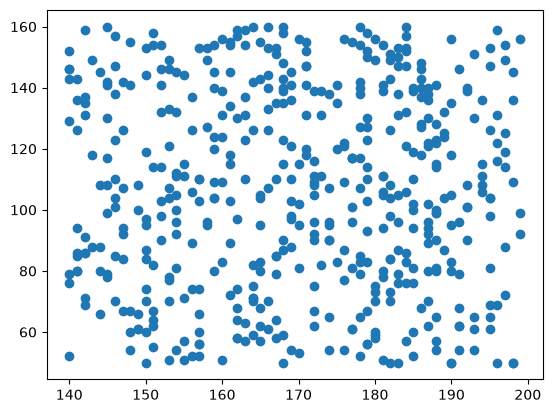

In [31]:
# 데이터 시각화
# 산점도 그래프 그려보기
plt.scatter(data['Height'], data['Weight'])
plt.show()

In [33]:
data.loc['Normal']

,Gender,Height,Weight
Label,,,
Normal,Male,189,87
Normal,Male,195,81
Normal,Male,155,51
Normal,Male,191,79
Normal,Female,172,67
...,...,...,...
Normal,Female,178,65
Normal,Male,167,64
Normal,Female,151,55


In [34]:
# 비만도 등급 별 시각화

# 키와 몸무게 데이터를 등급별로 구분하여 산점도를 표시하는 함수를 만들어보자!
def bmi_scatter(label, color) : # 매개변수 비만도 등금(label), 그래프 색깔
    
    # 입력한 라벨에 대한 데이터만 추출
    temp = data.loc[label]

    # 산점도 그래프 출력
    plt.scatter(temp['Height'], temp['Weight'], 
                c = color, #색깔 설정 
                label = label) # 범례 출력시 라벨 설정

In [35]:
#plt.scatter() # 함수 툴팁 확인 : shift + tab

In [37]:
data.index.unique() #라벨 확인하기

Index(['Obesity', 'Normal', 'Overweight', 'Extreme Obesity', 'Weak',
       'Extremely Weak'],
      dtype='str', name='Label')

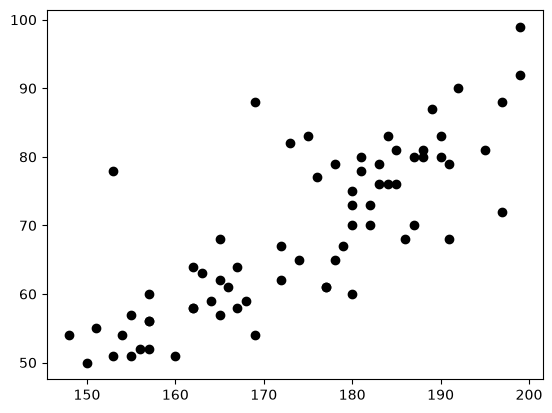

In [36]:
bmi_scatter('Normal', 'black')

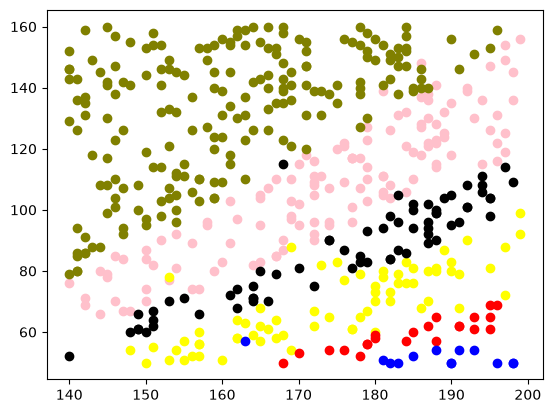

In [38]:
bmi_scatter('Obesity', 'pink')
bmi_scatter('Normal', 'yellow')
bmi_scatter('Overweight', 'black')
bmi_scatter('Extreme Obesity', 'olive')
bmi_scatter('Weak', 'red')
bmi_scatter('Extremely Weak', 'blue')

plt.legend() # 범례 표시
plt.show()

#### 5. 모델 선택 및 하이퍼파라미터 조정
1. 문제(X) / 정답(y) 분리
2. train, test 세트로 분리 - 7:3
3. 모델 객체 생성
  

In [67]:
# 인덱스 값으로 해놓았던 라벨컬럼을 다시 원래 컬럼 자리로 되돌리기
data = data.reset_index()
data.head(10) #숫자 안넣으면 기본값 5로 보여준다.

,index,Label,Gender,Height,Weight
0,0,Obesity,Male,174,96
1,1,Normal,Male,189,87
2,2,Obesity,Female,185,110
3,3,Overweight,Female,195,104
4,4,Overweight,Male,149,61
5,5,Overweight,Male,189,104
6,6,Extreme Obesity,Male,147,92
7,7,Extreme Obesity,Male,154,111
8,8,Overweight,Male,174,90
9,9,Obesity,Female,169,103


In [68]:
# 문제, 정답 분리
# X 변수에 Height Weight 컬럼 담아주기
# y 변수에 Label 컬럼 담아주기
# X.shape, y.shape 가
# ((500, 2), (500, )) 처럼 나오면 됨
X = data[['Height', 'Weight']]   # X = data.loc[:,'Height':'Weight'] 처럼 해도 됨
y = data['Label']                # y = data.loc[:,'Label']
print(X.shape)
print(y.shape)

(500, 2)
(500,)


In [69]:
# 훈련용 / 평가용 분리 (7:3 -> 350개 / 150개)
X_train = X.loc[0:349,:] # = X[:350]
X_test = X.loc[350:,:]  # = X[350:]
y_train = y.loc[0:349]  # = y[:350]
y_test = y.loc[350:]   # = y[350:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

# 단순 슬라이싱은 좋은 방법은 아님(ex> 데이터가 정렬되어 있을 경우에
#                                   학습이 제대로 되지 않을 수 있다!! 왜냐하면 인덱스 값이 잘려서 학습될수 있으니까)
# 데이터 분리 도구 활용이 권장됨 !!

# 데이터 분리 시 꼭 shape 확인 !!
# 1. train / test 행의 개수 일치 하는지 확인하기!!
# 2. 사용하고자 하는 컬럼(입력 특성)의 개수 -> 키/몸무게 2개
# 3. 문제데이터(X) -> 2차원, 정답데이터(y) -> 1차원

((350, 2), (150, 2), (350,), (150,))

In [70]:
# 모델 불러오기 사이언스키트런
from sklearn.neighbors import KNeighborsClassifier # 최근접 이웃 분류 모델

In [71]:
# 모델 객체 생성 및 하이퍼파라미터 조정
knn_model = KNeighborsClassifier(n_neighbors=3)
# 거리가 가장 가까운 이웃 3개의 실제 정답을 보면서 예측을 수행하는 모델
# knn거리공식이 있는데 피타고라스의 정리와 같은 개념임. 밑변과 높이의 길이를 알면 빗변의 길이를 알수있는.

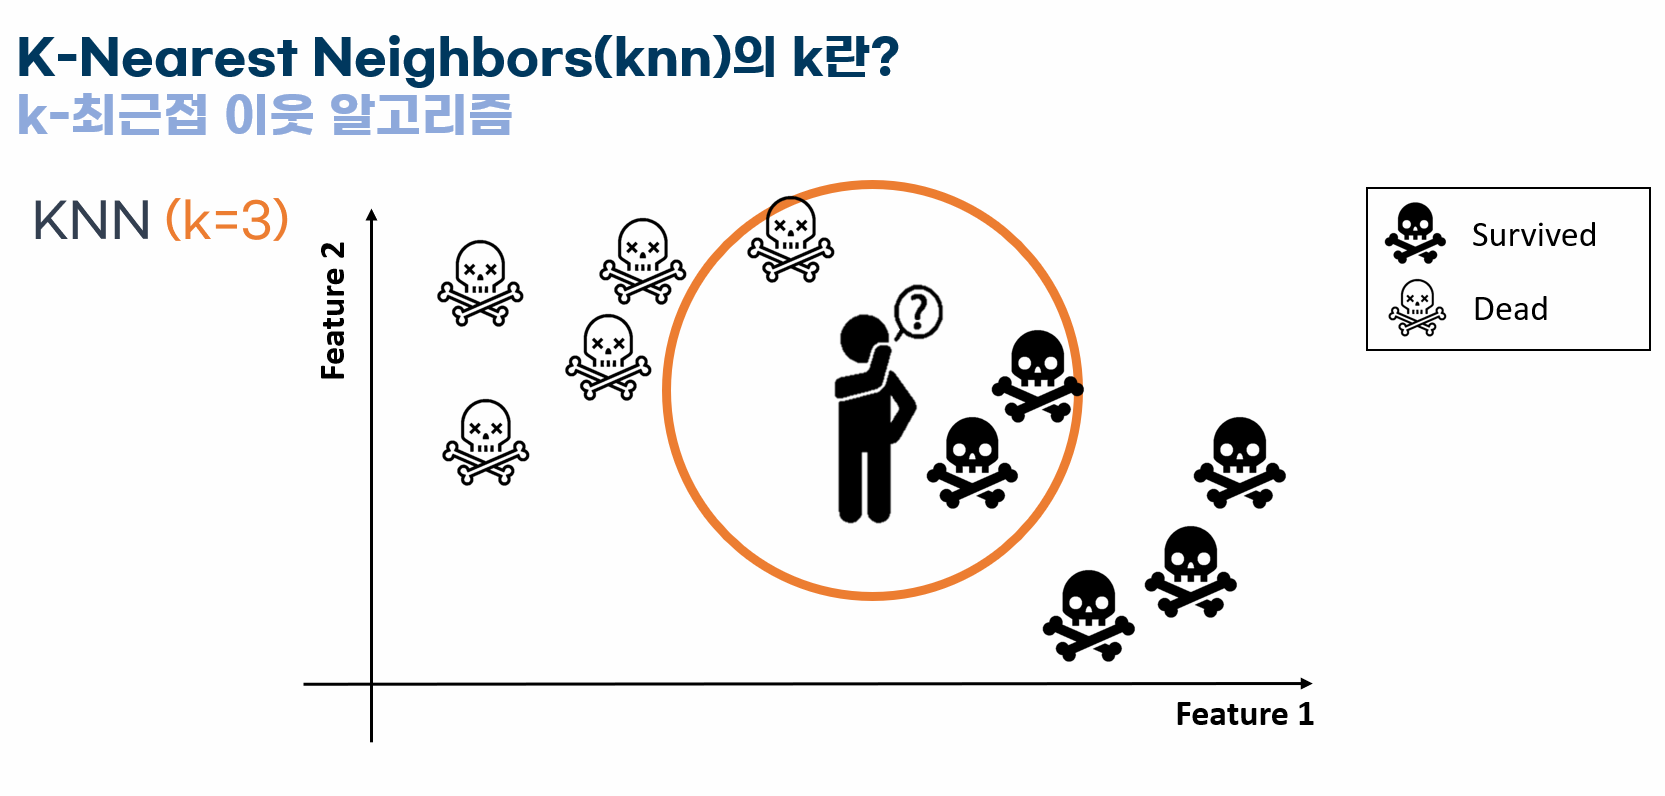

### 6. 모델 학습

In [72]:
from sklearn import set_config
set_config(display = 'text')

In [73]:
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

### 7. 모델 평가

In [74]:
# 학습되어 있는 모델에 대한 점수 확인
# 분류 -> 정확도
# 회귀 -> 유사도(R2-score)
print(knn_model.score(X_train, y_train))

# 다른 평가지표를 확인하고 싶다면? 각각의 평가 도구를 불러와서 사용 가능하다!
from sklearn.metrics import accuracy_score #정확도
from sklearn.metrics import recall_score # 재현율

0.9342857142857143


In [75]:
knn_model.score(X_test, y_test)

# k = 3 -> 0.9
# k = 13일 때 우수한 성능을 보이는 것으로 추정!!
# 이웃의 수에 따라서 모델의 성능이 변화
# 이웃의 수 = 하이퍼 파라미터 : 사용자가 적절하게 조정해줘야 하는 값

0.9

In [76]:
# 모델한테 내 키와 몸무게를 넣어서 결과 확인해보자 ~~
knn_model.predict([[170.2, 62]])

C:\Users\smhrd\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Normal'], dtype=object)